In [6]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, precision_score, recall_score

In [7]:
results = []

### Utility Functions

In [8]:
def evaluate_model(x_test, y_test, model, model_name):
    print("="*50,model_name,"="*50, sep="\n")
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print("Accuracy : \n",accuracy_score(y_test,y_pred))
    print("\nConfusion Matrix : \n", confusion_matrix(y_test, y_pred))
    print("\nClassification_Report : \n", classification_report(y_test, y_pred))
    return y_pred, accuracy, precision, recall, f1

In [9]:
def add_result(model_name, accuracy, precision, recall, f1):
    results.append({
        "Model" : model_name,
        "Accuracy" : accuracy,
        "Precision" : precision,
        "Recall" : recall,
        "F1-Score" : f1
    })

In [10]:
import os
os.listdir("../data")

['.ipynb_checkpoints', 'processed_data', 'rawData', 'raw_data']

In [11]:
os.listdir("../data/processed_data")

['.ipynb_checkpoints',
 'x_test.csv',
 'x_train.csv',
 'y_test.csv',
 'y_train.csv']

In [12]:
x_train_scaled = pd.read_csv("../data/processed_data/x_train.csv")
x_test_scaled = pd.read_csv("../data/processed_data/x_test.csv")
y_train = pd.read_csv("../data/processed_data/y_train.csv").squeeze("columns")
y_test = pd.read_csv("../data/processed_data/y_test.csv").squeeze("columns")

In [13]:
y_train.head()

0    0
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64

### Using Logistic Regression as first model

In [14]:
from sklearn.linear_model import LogisticRegression

In [15]:
clf = LogisticRegression(random_state=0)

In [16]:
clf.fit(x_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver

In [17]:
y_pred = clf.predict(x_test_scaled)

In [18]:
y_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [19]:
np.array(y_test.head(10))

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [20]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8695652173913043

In [21]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[299,  10],
       [ 38,  21]])

In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.97      0.93       309
           1       0.68      0.36      0.47        59

    accuracy                           0.87       368
   macro avg       0.78      0.66      0.70       368
weighted avg       0.85      0.87      0.85       368



In [23]:
y_pred, accuracy, precision, recall, f1_clf = evaluate_model(x_test_scaled, y_test, clf, "LoggisticRegression") 

LoggisticRegression
Accuracy : 
 0.8695652173913043

Confusion Matrix : 
 [[299  10]
 [ 38  21]]

Classification_Report : 
               precision    recall  f1-score   support

           0       0.89      0.97      0.93       309
           1       0.68      0.36      0.47        59

    accuracy                           0.87       368
   macro avg       0.78      0.66      0.70       368
weighted avg       0.85      0.87      0.85       368



In [24]:
add_result?

Signature: add_result(model_name, accuracy, precision, recall, f1)
Docstring: <no docstring>
File:      c:\users\goutam\appdata\local\temp\ipykernel_11812\963406110.py
Type:      function

In [25]:
add_result("LogisticRegression", accuracy, precision, recall, f1_clf)

In [26]:
pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1-Score
0,LogisticRegression,0.869565,0.677419,0.355932,0.466667


### Now we will run K-NN


In [27]:
from sklearn.neighbors import KNeighborsClassifier

In [28]:
knn = KNeighborsClassifier(n_neighbors=5)

In [29]:
knn.fit(x_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [30]:
y_pred_knn = knn.predict(x_test_scaled)

In [31]:
accuracy = accuracy_score(y_test, y_pred_knn)
accuracy

0.8396739130434783

In [32]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_knn

array([[303,   6],
       [ 53,   6]])

In [33]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.85      0.98      0.91       309
           1       0.50      0.10      0.17        59

    accuracy                           0.84       368
   macro avg       0.68      0.54      0.54       368
weighted avg       0.79      0.84      0.79       368



### Trying out different values of K

In [34]:
accuracies = []
k_values = []
for k in range(1,31):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train_scaled, y_train)
    y_pred = knn.predict(x_test_scaled)
    accuracy = accuracy_score(y_pred, y_test)
    k_values.append(k)
    accuracies.append(accuracy)

In [35]:
np.array(accuracies)

array([0.7826087 , 0.83423913, 0.82065217, 0.8451087 , 0.83967391,
       0.8451087 , 0.8451087 , 0.8451087 , 0.84782609, 0.8451087 ,
       0.8423913 , 0.8423913 , 0.8451087 , 0.8451087 , 0.8451087 ,
       0.83967391, 0.8423913 , 0.83967391, 0.83967391, 0.8423913 ,
       0.8451087 , 0.8451087 , 0.8451087 , 0.8423913 , 0.8423913 ,
       0.8423913 , 0.8423913 , 0.83967391, 0.83967391, 0.83967391])

In [36]:
import matplotlib.pyplot as plt

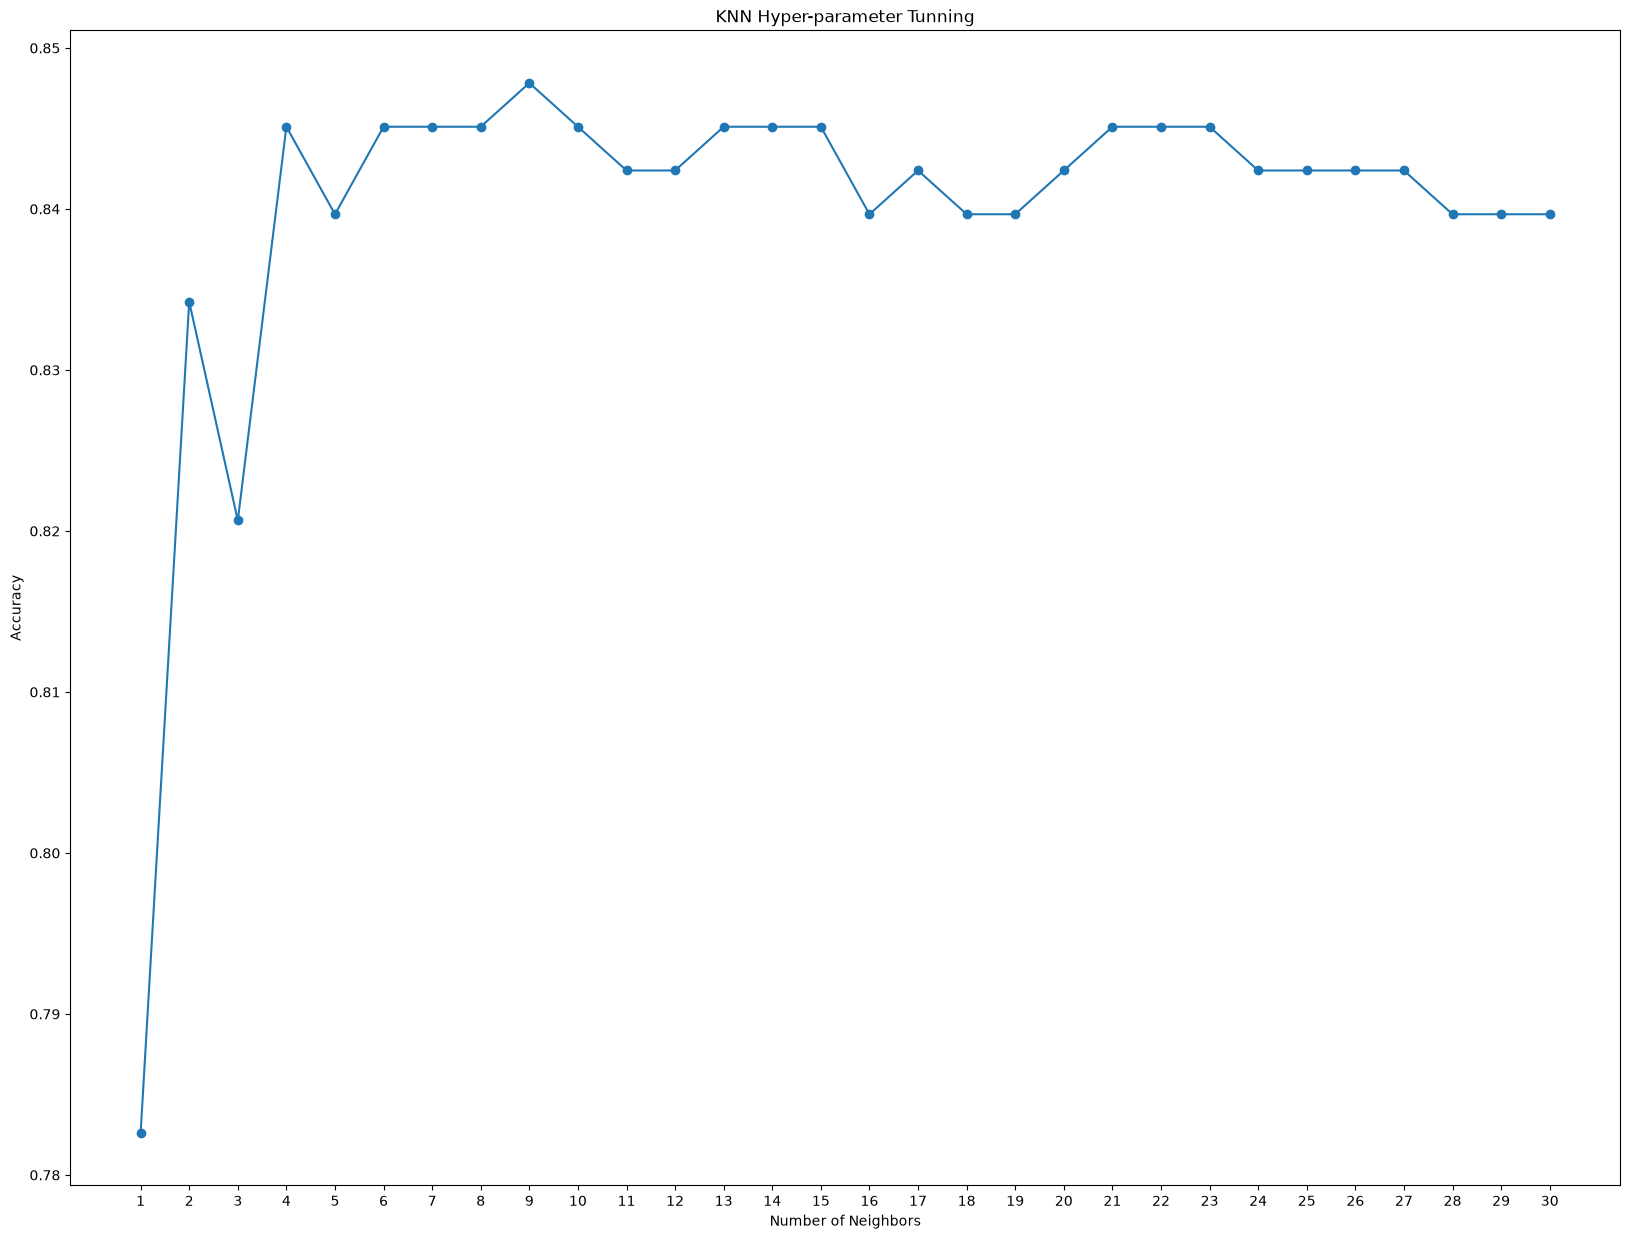

In [37]:
plt.figure(figsize=(20,15))
plt.plot(k_values, accuracies, marker='o')
plt.title("KNN Hyper-parameter Tunning")
plt.xlabel("Number of Neighbors")
plt.ylabel("Accuracy")

plt.xticks(range(1,31))

plt.show()

In [38]:
best_accuracy_knn = max(accuracies)

In [39]:
best_k_knn = k_values[accuracies.index(best_accuracy_knn)]

In [40]:
print("Best k : ",best_k_knn)
print("Best accuracy : ",best_accuracy_knn)

Best k :  9
Best accuracy :  0.8478260869565217


In [41]:
best_knn = KNeighborsClassifier(n_neighbors=best_k_knn)

In [42]:
best_knn.fit(x_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",9
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [43]:
y_pred_best_knn = best_knn.predict(x_test_scaled)

In [44]:
accuracy = accuracy_score(y_test ,y_pred_best_knn)
accuracy

0.8478260869565217

In [45]:
cm = confusion_matrix(y_test, y_pred_best_knn)
cm

array([[308,   1],
       [ 55,   4]])

In [46]:
print(classification_report(y_test ,y_pred_best_knn))

              precision    recall  f1-score   support

           0       0.85      1.00      0.92       309
           1       0.80      0.07      0.12        59

    accuracy                           0.85       368
   macro avg       0.82      0.53      0.52       368
weighted avg       0.84      0.85      0.79       368



In [47]:
y_pred_knn, accuracy_knn, precision_knn, recall_knn, f1_knn = evaluate_model(x_test_scaled,y_test,best_knn, "KNN")

KNN
Accuracy : 
 0.8478260869565217

Confusion Matrix : 
 [[308   1]
 [ 55   4]]

Classification_Report : 
               precision    recall  f1-score   support

           0       0.85      1.00      0.92       309
           1       0.80      0.07      0.12        59

    accuracy                           0.85       368
   macro avg       0.82      0.53      0.52       368
weighted avg       0.84      0.85      0.79       368



In [48]:
add_result?

Signature: add_result(model_name, accuracy, precision, recall, f1)
Docstring: <no docstring>
File:      c:\users\goutam\appdata\local\temp\ipykernel_11812\963406110.py
Type:      function

In [49]:
add_result("KNN", accuracy_knn, precision_knn, recall_knn, f1_knn)

### Using Decision Trees

In [50]:
from sklearn.tree import DecisionTreeClassifier

In [51]:
dt = DecisionTreeClassifier(random_state=0)

In [52]:
dt.fit(x_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",0
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [53]:
y_pred_dt, dt_accuracy, dt_precision, dt_recall, dt_f1 = evaluate_model(x_test_scaled,y_test,dt,"DecisionTree")

DecisionTree
Accuracy : 
 0.7472826086956522

Confusion Matrix : 
 [[258  51]
 [ 42  17]]

Classification_Report : 
               precision    recall  f1-score   support

           0       0.86      0.83      0.85       309
           1       0.25      0.29      0.27        59

    accuracy                           0.75       368
   macro avg       0.55      0.56      0.56       368
weighted avg       0.76      0.75      0.75       368



In [54]:
add_result("DecisionTreeClassifier_defaultParams", dt_accuracy, dt_precision, dt_recall, dt_f1)

In [55]:
print("Training Accuracy:", dt.score(x_train_scaled, y_train))
print("Testing Accuracy:", dt.score(x_test_scaled, y_test))

Training Accuracy: 1.0
Testing Accuracy: 0.7472826086956522


- the default decision tree many times tends to overfit...so we have to tune the hyperparameter

### Hyper-parameter tunning for decision tree

In [56]:
depths = []
accuracies_dt = []
for depth in range(1,21):
    dt = DecisionTreeClassifier(max_depth=depth, random_state=0)
    dt.fit(x_train_scaled, y_train)
    y_pred_dt = dt.predict(x_test_scaled)
    accuracy = accuracy_score(y_test,y_pred_dt)
    depths.append(depth)
    accuracies_dt.append(accuracy)

In [57]:
np.array(accuracies_dt)

array([0.79347826, 0.83695652, 0.82880435, 0.82608696, 0.81521739,
       0.80434783, 0.79619565, 0.78532609, 0.7826087 , 0.74728261,
       0.76630435, 0.73913043, 0.74728261, 0.73913043, 0.74728261,
       0.74728261, 0.74728261, 0.74728261, 0.74728261, 0.74728261])

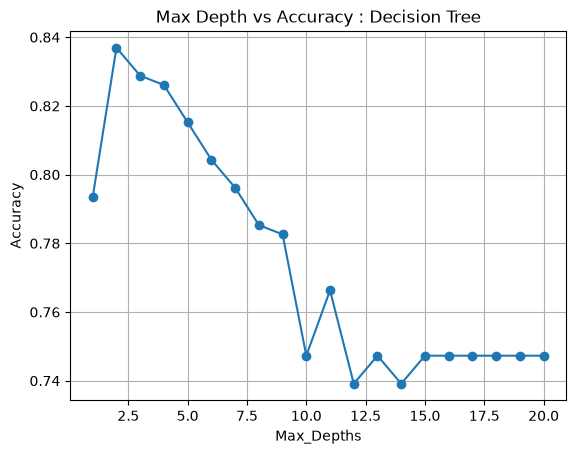

In [58]:
plt.plot(depths, accuracies_dt, marker='o')
plt.title("Max Depth vs Accuracy : Decision Tree")
plt.xlabel("Max_Depths")
plt.ylabel("Accuracy")

plt.grid(True)
plt.show()

In [59]:
max_accuracy_knn = max(accuracies_dt)
max_accuracy_knn

0.8369565217391305

In [60]:
max_depth_knn = depths[accuracies_dt.index(max_accuracy_knn)]
max_depth_knn

2

#### Using GridSearchCV to tune decision tree hyperparameters easily

In [61]:
from sklearn.model_selection import GridSearchCV

In [62]:
dt = DecisionTreeClassifier(random_state=0)

param_grid = {
    "max_depth" : [2,4,6,8,10],
    "min_samples_split" : [2,5,10],
    "criterion" : ["gini", "entropy"]
}

- 7 depths x 3 split values x 2 criteria => 42 models

In [63]:
grid_search = GridSearchCV(
    estimator = dt,
    param_grid = param_grid,
    scoring = "accuracy",
    cv=5, #cv means cross validation
    n_jobs = -1 #Use all CPU cores available
)

In [64]:
grid_search.fit(x_train_scaled,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [2, 4, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default

In [65]:
grid_search.best_params_

{'criterion': 'gini', 'max_depth': 4, 'min_samples_split': 10}

In [66]:
grid_search.best_score_

np.float64(0.8502673796791445)

In [67]:
best_dt = grid_search.best_estimator_

In [68]:
best_dt_y_pred, best_dt_accuracy, best_dt_precision, best_dt_recall, best_dt_f1 = evaluate_model(x_test_scaled, y_test, best_dt, "DecisionTreeClassifier")

DecisionTreeClassifier
Accuracy : 
 0.8233695652173914

Confusion Matrix : 
 [[290  19]
 [ 46  13]]

Classification_Report : 
               precision    recall  f1-score   support

           0       0.86      0.94      0.90       309
           1       0.41      0.22      0.29        59

    accuracy                           0.82       368
   macro avg       0.63      0.58      0.59       368
weighted avg       0.79      0.82      0.80       368



In [69]:
add_result("DecisionTreeClassifier_GridSearchCV", best_dt_accuracy, best_dt_precision, best_dt_recall, best_dt_f1)

In [70]:
pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1-Score
0,LogisticRegression,0.869565,0.677419,0.355932,0.466667
1,KNN,0.847826,0.800000,0.067797,0.125000
2,DecisionTreeClassifier_defaultParams,0.747283,0.250000,0.288136,0.267717
3,DecisionTreeClassifier_GridSearchCV,0.823370,0.406250,0.220339,0.285714


### Implementing Naive-Bayes

In [71]:
from sklearn.naive_bayes import GaussianNB

In [72]:
naive = GaussianNB()

In [73]:
naive.fit(x_train_scaled, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[924.,178.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.84,0.16]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1e-09
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](44,)","['Age','DailyRate','DistanceFromHome',...,'MaritalStatus_Married', 'MaritalStatus_Single','OverTime_Yes']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,44
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 44)","[[ 0.08, 0.03,-0.04,..., 0.48, 0.29, 0.25], [-0.41,-0.17, 0.21,..., 0.34, 0.51, 0.52]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 44)","[[0.95,0.99,0.97,...,0.25,0.2 ,0.19], [1.04,1. ,1.11,...,0.22,0.25,0.25]]"


In [74]:
help(evaluate_model)

Help on function evaluate_model in module __main__:

evaluate_model(x_test, y_test, model, model_name)



In [75]:
help(add_result)

Help on function add_result in module __main__:

add_result(model_name, accuracy, precision, recall, f1)



In [76]:
y_pred_naive, accuracy_naive, precision_naive, recall_naive, f1_naive = evaluate_model(x_test_scaled, y_test, naive, "GaussianNV")

GaussianNV
Accuracy : 
 0.6603260869565217

Confusion Matrix : 
 [[203 106]
 [ 19  40]]

Classification_Report : 
               precision    recall  f1-score   support

           0       0.91      0.66      0.76       309
           1       0.27      0.68      0.39        59

    accuracy                           0.66       368
   macro avg       0.59      0.67      0.58       368
weighted avg       0.81      0.66      0.70       368



In [77]:
add_result("GaussianNB_default", accuracy_naive, precision_naive, recall_naive, f1_naive)

In [78]:
pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1-Score
0,LogisticRegression,0.869565,0.677419,0.355932,0.466667
1,KNN,0.847826,0.800000,0.067797,0.125000
2,DecisionTreeClassifier_defaultParams,0.747283,0.250000,0.288136,0.267717
3,DecisionTreeClassifier_GridSearchCV,0.823370,0.406250,0.220339,0.285714
4,GaussianNB_default,0.660326,0.273973,0.677966,0.390244


### Tunning The Hyper-Parameter for Gaussian_Naive_Bayes

In [79]:
grid_search_naive= GridSearchCV(
    estimator = naive,
    param_grid = {
        "var_smoothing" : [1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7]
    },
    scoring = "f1",
    cv = 5,
    n_jobs = -1
)

In [80]:
grid_search_naive.fit(x_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GaussianNB()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'var_smoothing': [1e-12, 1e-11, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalue

In [81]:
grid_search_naive.best_score_

np.float64(0.3953682009917858)

In [82]:
best_naive = grid_search_naive.best_estimator_

In [83]:
y_pred_best_naive, accuracy_best_naive, precision_best_naive, recall_best_naive, f1_best_naive = evaluate_model(x_test_scaled, y_test, best_naive, "GaussianNV_Tunned")

GaussianNV_Tunned
Accuracy : 
 0.6603260869565217

Confusion Matrix : 
 [[203 106]
 [ 19  40]]

Classification_Report : 
               precision    recall  f1-score   support

           0       0.91      0.66      0.76       309
           1       0.27      0.68      0.39        59

    accuracy                           0.66       368
   macro avg       0.59      0.67      0.58       368
weighted avg       0.81      0.66      0.70       368



In [84]:
add_result("GaussianNV_Tunned", accuracy_best_naive, precision_best_naive, recall_best_naive, f1_best_naive)

In [85]:
add_result?

Signature: add_result(model_name, accuracy, precision, recall, f1)
Docstring: <no docstring>
File:      c:\users\goutam\appdata\local\temp\ipykernel_11812\963406110.py
Type:      function

In [86]:
pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1-Score
0,LogisticRegression,0.869565,0.677419,0.355932,0.466667
1,KNN,0.847826,0.800000,0.067797,0.125000
2,DecisionTreeClassifier_defaultParams,0.747283,0.250000,0.288136,0.267717
3,DecisionTreeClassifier_GridSearchCV,0.823370,0.406250,0.220339,0.285714
4,GaussianNB_default,0.660326,0.273973,0.677966,0.390244
5,GaussianNV_Tunned,0.660326,0.273973,0.677966,0.390244


### Using Soft-Vector-Machine(SVM)

In [87]:
from sklearn.svm import SVC
# SVC = Support Vector Classifier

In [88]:
svm = SVC()

In [89]:
svm.fit(x_train_scaled,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [90]:
y_pred_svm, accuracy_svm, precision_svm, recall_svm, f1_svm = evaluate_model(x_test_scaled, y_test, svm, "Support Vector Machine")

Support Vector Machine
Accuracy : 
 0.8641304347826086

Confusion Matrix : 
 [[307   2]
 [ 48  11]]

Classification_Report : 
               precision    recall  f1-score   support

           0       0.86      0.99      0.92       309
           1       0.85      0.19      0.31        59

    accuracy                           0.86       368
   macro avg       0.86      0.59      0.62       368
weighted avg       0.86      0.86      0.83       368



In [91]:
add_result("Support Vector Machine_default", accuracy_svm, precision_svm, recall_svm, f1_svm)

In [92]:
pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1-Score
0,LogisticRegression,0.869565,0.677419,0.355932,0.466667
1,KNN,0.847826,0.800000,0.067797,0.125000
2,DecisionTreeClassifier_defaultParams,0.747283,0.250000,0.288136,0.267717
3,DecisionTreeClassifier_GridSearchCV,0.823370,0.406250,0.220339,0.285714
4,GaussianNB_default,0.660326,0.273973,0.677966,0.390244
5,GaussianNV_Tunned,0.660326,0.273973,0.677966,0.390244
6,Support Vector Machine_default,0.864130,0.846154,0.186441,0.305556


### SVM Hyper-parameter Tunning

In [93]:
svm?

Type:        SVC
String form: SVC()
File:        c:\users\goutam\miniconda3\envs\my_projects\lib\site-packages\sklearn\svm\_classes.py
Docstring:  
C-Support Vector Classification.

The implementation is based on libsvm. The fit time scales at least
quadratically with the number of samples and may be impractical
beyond tens of thousands of samples. For large datasets
consider using :class:`~sklearn.svm.LinearSVC` or
:class:`~sklearn.linear_model.SGDClassifier` instead, possibly after a
:class:`~sklearn.kernel_approximation.Nystroem` transformer or
other :ref:`kernel_approximation`.

The multiclass support is handled according to a one-vs-one scheme.

For details on the precise mathematical formulation of the provided
kernel functions and how `gamma`, `coef0` and `degree` affect each
other, see the corresponding section in the narrative documentation:
:ref:`svm_kernels`.

To learn how to tune SVC's hyperparameters, see the following example:
:ref:`sphx_glr_auto_examples_model_selection_

In [94]:
grid_svm = SVC()

In [95]:
grid_search_svm = GridSearchCV(
    estimator = grid_svm,
    param_grid = {
        "C" : [0.01, 0.1, 1, 10, 100],
    },
    scoring = "f1",
    n_jobs = -1,
    cv = 5
)

In [96]:
grid_search_svm.fit(x_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detail

In [97]:
best_svm = grid_search_svm.best_estimator_

In [98]:
y_pred_best_svm, accuracy_best_svm, precision_best_svm, recall_best_svm, f1_best_svm = evaluate_model(x_test_scaled, y_test, best_svm, "Support Vector Machine_Tunned")

Support Vector Machine_Tunned
Accuracy : 
 0.8532608695652174

Confusion Matrix : 
 [[294  15]
 [ 39  20]]

Classification_Report : 
               precision    recall  f1-score   support

           0       0.88      0.95      0.92       309
           1       0.57      0.34      0.43        59

    accuracy                           0.85       368
   macro avg       0.73      0.65      0.67       368
weighted avg       0.83      0.85      0.84       368



In [99]:
add_result("Support Vector Machine_Tunned", accuracy_best_svm,  precision_best_svm, recall_best_svm, f1_svm)

In [100]:
pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1-Score
0,LogisticRegression,0.869565,0.677419,0.355932,0.466667
1,KNN,0.847826,0.800000,0.067797,0.125000
2,DecisionTreeClassifier_defaultParams,0.747283,0.250000,0.288136,0.267717
3,DecisionTreeClassifier_GridSearchCV,0.823370,0.406250,0.220339,0.285714
4,GaussianNB_default,0.660326,0.273973,0.677966,0.390244
5,GaussianNV_Tunned,0.660326,0.273973,0.677966,0.390244
6,Support Vector Machine_default,0.864130,0.846154,0.186441,0.305556
7,Support Vector Machine_Tunned,0.853261,0.571429,0.338983,0.305556


## Saving the Best Model

In [101]:
results = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)

In [102]:
import joblib

In [103]:
joblib.dump(clf, "../models/logistic_regression.pkl")

['../models/logistic_regression.pkl']